In [40]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker
import random

An e-commerce company wants to analyze its sales performance across product categories over time.
Problem Statement
Create a dataset of at least 500 orders containing:


order_id, order_date, customer_id, product_category, price, quantity, discount_percent


Using Pandas:


Compute the final order amount after discount.


Calculate monthly revenue per product category.


Identify the top three categories by total revenue.

Using NumPy:

Detect unusually high or low order values.

Replace detected anomalies using a statistically valid method.

Using a visualization library:

Plot monthly revenue trends.

Compare revenue distribution across categories.

In [41]:
fake=Faker()
data=[]
product_categories = ['Electronics', 'Clothing', 'Books', 'Home', 'Toys']
for i in range(500):
    data.append({
        "order_id":fake.uuid4(),
        "order_date":fake.date(),
        "customer_id":fake.random_int(min=100,max=9999),
        "product_category":random.choice(product_categories),
        "price":fake.random_int(min=500,max=50000),
        "quantity":random.randint(1,10),
        "discount_percent":random.choice([0,5,10,15,20,25,30])
    })
    df=pd.DataFrame(data)
    df.to_csv("E_Commerce_Sales_Analysis.csv",index=False)
    
    

In [42]:
df=pd.read_csv("E_Commerce_Sales_Analysis.csv")
df["final_amount"]=df["price"]*df["quantity"]*(1-df["discount_percent"]/100)
df.head(10)

,order_id,order_date,customer_id,product_category,price,quantity,discount_percent,final_amount
0,14af6de1-03dd-4d81-90c7-5346a14d45c7,2002-04-20,8652,Electronics,39112,6,25,176004.0
1,2cc302c0-d3ab-4da5-8f56-3c3f90709446,1980-02-06,6504,Toys,49711,10,30,347977.0
2,ee0784f9-85e8-47cd-b6ae-f857ce9ebeed,2010-10-21,312,Home,19092,3,25,42957.0
3,b918142c-5039-4df5-b2bd-08d5963551ed,2019-01-19,4905,Books,7428,9,5,63509.4
4,97a29443-5c80-4e81-8bac-7110be99cd33,2013-12-09,6609,Electronics,47703,4,0,190812.0
5,adec6086-fd9c-419f-8db1-68195c848af8,2002-11-18,9012,Books,30080,7,0,210560.0
6,2e3e3b84-c540-4123-866a-bc4d68231cb0,2022-03-26,8324,Clothing,30377,10,30,212639.0
7,3ec7b69d-0bf8-468e-b8f8-ad95ee3e1b59,2022-03-02,7465,Toys,22305,2,20,35688.0
8,30a5a2e0-a56a-4f1c-85db-4dc0d8cddb1c,1987-01-28,7401,Toys,20747,6,30,87137.4
9,53218aa4-9434-4988-8633-94d76ebe1bbc,1984-05-08,4381,Electronics,23859,8,5,181328.4


In [43]:
df["order_date"]=pd.to_datetime(df["order_date"])
# extract month details in month col
df["month"]=df["order_date"].dt.to_period("M")
monthly_rev=df.groupby(["month","product_category"])["final_amount"].sum()
print(monthly_rev.head(10))


month    product_category
1970-01  Clothing             75710.70
         Electronics         256200.75
1970-07  Electronics          49404.60
1970-08  Electronics         133305.60
1970-09  Home                 47815.05
         Toys                223041.70
1970-10  Books               452225.10
1970-11  Toys                 95696.00
1971-04  Home                181600.00
1971-05  Home                 14499.00
Name: final_amount, dtype: float64


Identify the top three categories by total revenue

In [44]:
category1=df.groupby("product_category")["final_amount"].sum()
category1=category1.sort_values(ascending=False)
top3=category1.head(3)
print(top3)

product_category
Electronics    13301604.75
Clothing       12650136.65
Toys           11563214.75
Name: final_amount, dtype: float64


Detect unusually high or low order values.

In [45]:
arr=df["final_amount"].values
mean=np.mean(arr)
std=np.std(arr)
z_score=(arr-mean)/std
thershold=3

outliers=df[np.abs(z_score)>thershold]
print(outliers)

                                 order_id order_date  customer_id  \
21   cfff7a90-9740-4be3-baa0-54c034559e73 2012-09-02         3172   
24   fb2d95a5-2be6-42dd-8893-06533b21cb4b 2006-06-24         5768   
120  a58b4ce8-7e25-4f9c-9d24-6821295b05e2 1982-05-29         4019   
184  eef39567-1a9a-4a34-bde7-1a054073b0e2 1980-11-17         1717   

    product_category  price  quantity  discount_percent  final_amount    month  
21          Clothing  45474        10                 5      432003.0  2012-09  
24              Home  47176         9                 0      424584.0  2006-06  
120             Home  47981        10                 5      455819.5  1982-05  
184      Electronics  42674        10                 0      426740.0  1980-11  


Replace detected anomalies(outliers) using a statistically valid method.

In [46]:
final_amount=df["final_amount"].copy()
mean=np.mean(final_amount)
std=np.std(final_amount)
z_score=(final_amount-mean)/std
thershold=3

median_value=final_amount[np.abs(z_score)<=thershold].median()
# calculated median to replace outliers with median value

df["final_amount_cleaned"]=final_amount.copy()
df.loc[np.abs(z_score)>thershold,"final_amount_cleaned"]=median_value
print(df[["final_amount","final_amount_cleaned"]].head(10))

   final_amount  final_amount_cleaned
0      176004.0              176004.0
1      347977.0              347977.0
2       42957.0               42957.0
3       63509.4               63509.4
4      190812.0              190812.0
5      210560.0              210560.0
6      212639.0              212639.0
7       35688.0               35688.0
8       87137.4               87137.4
9      181328.4              181328.4


Using a visualization library:

Plot monthly revenue trends.


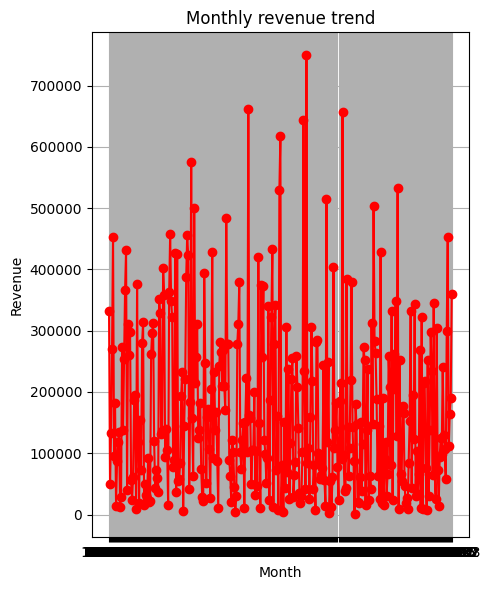

In [47]:
monthly_rev = df.groupby("month")["final_amount"].sum().reset_index()
x=monthly_rev["month"].astype(str) #convert period obj to string
y=monthly_rev["final_amount"]
plt.figure(figsize=(5,6))#5 wide 6 inch tall
plt.plot(x,y,marker="o",color="red")
plt.title("Monthly revenue trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()#labels and title not overlap
plt.show()


Compare revenue distribution across categories.

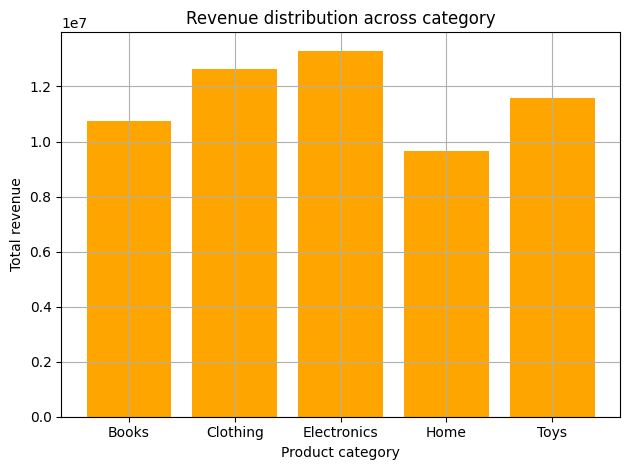

In [48]:
category_rev=df.groupby("product_category")["final_amount"].sum().reset_index()
a=category_rev["product_category"]
b=category_rev["final_amount"]
color=["red","orange","blue","yellow"]
plt.bar(a,b,color=random.choice(color))
plt.grid()
plt.xlabel("Product category")
plt.ylabel("Total revenue")
plt.title("Revenue distribution across category")

plt.tight_layout()
plt.show()